# Length Convergence

In typical RNEMD studies, they regression $\kappa$ versus $1/L$ in order to determine the "infinite-length limit $\kappa$". We do the same here.

Set `METRIC` in the cell below to switch what is analyzed:
- `"kappa"` — thermal conductivity, fit as $1/\kappa$ vs $1/L$ (intercept gives $\kappa_{\mathrm{bulk}}$).
- `"R_K"` — Kapitza / interfacial resistance, fit as $R_K$ vs $1/L$ (intercept gives the infinite-length $R_K$).

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from ase.io import read

GPUMD_ROOT = Path("/gpfs/home/djr2473/PSED/gpumd")

CONFIGS = [
    # "short",
    "medium",
    "long",
    "xlong"
]

GB_LABEL = "100_sigma5_100"

# --- which quantity to analyze ---
# "kappa": thermal conductivity, regressed as 1/κ vs 1/L (intercept → κ_bulk)
# "R_K":   Kapitza (interfacial) resistance, regressed as R_K vs 1/L
METRIC = "R_K"  # "kappa" or "R_K"

# per-metric settings: which summary column, the y-transform applied before the
# linear fit, and how to recover the physical infinite-length value.
METRIC_SETTINGS = {
    "kappa": {
        "column": "kappa_SI",
        "raw_unit": "W/m·K",
        "raw_label": "κ",
        "transform": lambda x: 1.0 / x,            # y = 1/κ
        "transform_err": lambda x, s: s / x**2,    # σ(1/κ) = σ(κ)/κ²
        "y_label": "1/κ  (m K W⁻¹)",
        "y_name": "1/κ",
        "y_unit": "m·K/W",
        "y_tex": r"1/\kappa",
        "bulk_from_intercept": lambda b: 1.0 / b,  # κ_bulk = 1/intercept
        "bulk_tex": r"\kappa",
        "bulk_unit": "W/(m·K)",
    },
    "R_K": {
        "column": "R_K_SI",
        "raw_unit": "K·m²/W",
        "raw_label": "R_K",
        "transform": lambda x: x,                  # y = R_K (already a resistance)
        "transform_err": lambda x, s: s,
        "y_label": "R_K  (K m² W⁻¹)",
        "y_name": "R_K",
        "y_unit": "K·m²/W",
        "y_tex": r"R_K",
        "bulk_from_intercept": lambda b: b,        # R_K(∞) = intercept
        "bulk_tex": r"R_K",
        "bulk_unit": "K·m²/W",
    },
}
cfg = METRIC_SETTINGS[METRIC]

# --- get the chosen metric and length for each config ---
lengths_nm = []
metric_means, metric_stds = [], []

for config in CONFIGS:
    # metric from summary.csv
    summary_path = GPUMD_ROOT / "results" / config / "rnemd" / GB_LABEL / "summary.csv"
    df = pd.read_csv(summary_path)
    metric_means.append(df[cfg["column"]].mean())
    metric_stds.append(df[cfg["column"]].std(ddof=1))

    # length from structure.traj
    traj_path = GPUMD_ROOT / "results" / config / "gb_generation" / GB_LABEL / "run_0" / "structure.traj"
    atoms = read(str(traj_path))
    cell_z_nm = np.diag(atoms.cell[:])[2] / 10.0  # Å → nm
    lengths_nm.append(cell_z_nm)

lengths_nm = np.array(lengths_nm)
metric_means = np.array(metric_means)
metric_stds = np.array(metric_stds)

inv_L = 1.0 / lengths_nm
y_means = cfg["transform"](metric_means)
y_stds = cfg["transform_err"](metric_means, metric_stds)

print(f"Metric: {METRIC}")
print(f"Config          L (nm)    1/L (nm⁻¹)    "
      f"{cfg['raw_label']} mean ± std ({cfg['raw_unit']})    "
      f"{cfg['y_name']} mean ± std ({cfg['y_unit']})")
for c, L, iL, m, s, ym, ys in zip(CONFIGS, lengths_nm, inv_L, metric_means, metric_stds, y_means, y_stds):
    print(f"  {c:<14}  {L:7.2f}    {iL:.5f}       {m:.4e} ± {s:.4e}       {ym:.4e} ± {ys:.4e}")

Metric: R_K
Config          L (nm)    1/L (nm⁻¹)    R_K mean ± std (K·m²/W)    R_K mean ± std (K·m²/W)
  medium           200.94    0.00498       4.8291e-09 ± 4.8063e-10       4.8291e-09 ± 4.8063e-10
  long             301.41    0.00332       4.7059e-09 ± 4.3479e-10       4.7059e-09 ± 4.3479e-10
  xlong            401.83    0.00249       5.1531e-09 ± 4.9171e-10       5.1531e-09 ± 4.9171e-10


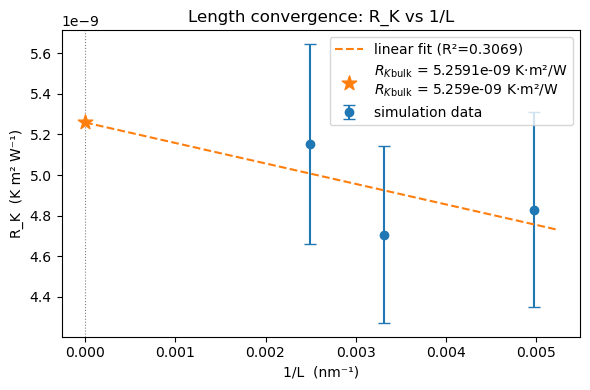


Linear fit:  R_K = 5.2591e-09 + -1.0101e-07 / L
R_K_bulk (intercept) = 5.2591e-09 K·m²/W
R_K_bulk               = 5.259e-09 K·m²/W  (R² = 0.3069)


In [10]:
# --- linear fit: y = intercept + slope * (1/L) ---
slope, intercept, r_value, p_value, std_err = stats.linregress(inv_L, y_means)
y_bulk = intercept
bulk_value = cfg["bulk_from_intercept"](y_bulk)

inv_L_fit = np.linspace(0, inv_L.max() * 1.05, 300)
y_fit = slope * inv_L_fit + intercept

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(inv_L, y_means, yerr=y_stds,
            fmt="o", color="C0", capsize=4, label="simulation data")
ax.plot(inv_L_fit, y_fit, "C1--", label=f"linear fit (R²={r_value**2:.4f})")
ax.axvline(0, color="gray", lw=0.8, ls=":")
# wrap the base symbol in braces so the "bulk" subscript applies to the whole
# group (otherwise e.g. R_K_{bulk} is a mathtext double-subscript error).
ax.scatter([0], [y_bulk], marker="*", s=120, color="C1", zorder=5,
           label=f"${{{cfg['y_tex']}}}_{{\\mathrm{{bulk}}}}$ = {y_bulk:.4e} {cfg['y_unit']}\n"
                 f"${{{cfg['bulk_tex']}}}_{{\\mathrm{{bulk}}}}$ = {bulk_value:.4g} {cfg['bulk_unit']}")

ax.set_xlabel("1/L  (nm⁻¹)")
ax.set_ylabel(cfg["y_label"])
ax.set_title(f"Length convergence: {cfg['y_name']} vs 1/L")
ax.legend()
fig.tight_layout()
plt.savefig(GPUMD_ROOT / "results" / f"length_convergence_{METRIC}.png", dpi=150)
plt.show()

print(f"\nLinear fit:  {cfg['y_name']} = {y_bulk:.4e} + {slope:.4e} / L")
print(f"{cfg['y_name']}_bulk (intercept) = {y_bulk:.4e} {cfg['y_unit']}")
print(f"{cfg['bulk_tex']}_bulk               = {bulk_value:.4g} {cfg['bulk_unit']}  (R² = {r_value**2:.4f})")